# Performance Notebook
**Course:** Numerical Scientific Computing  
**Environment:** Apple Silicon MacBook Air (10 logical cores, macOS) + AAU Strato cluster  
**Default grid:** N=1024, max_iter=100 (unless stated otherwise)

In [11]:
import matplotlib.pyplot as plt
import numpy as np

---
## MP2 — Section 1 — Multiprocessing
**Implementation:** `mandelbrot_parallel.py` `Pool.map` with chunked rows, Numba JIT workers  
**Hardware:** MacBook Air Apple Silicon, n_workers=5 (sweet spot from worker sweep)  
**Grid:** N=1024, max_iter=100

### 1.1 Serial baseline

In [24]:
t_serial_1024 = 0.035  # Numba single-core, median of 3 runs
print(f"Numba serial baseline (N=1024): {t_serial_1024:.3f}s")

Numba serial baseline (N=1024): 0.035s


### 1.2 Chunk sweep (L05-M2)
Fixed n_workers=5, n_chunks = [1x, 2x, 4x, 8x, 16x] * n_workers.

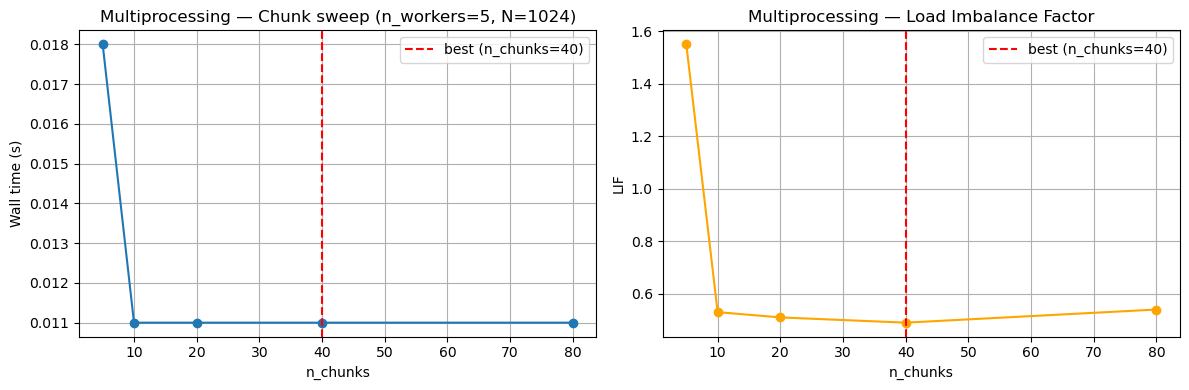

  n_chunks |  time (s) |  speedup |    LIF
--------------------------------------------
         5 |     0.018 |    1.96x |   1.55
        10 |     0.011 |    3.28x |   0.53
        20 |     0.011 |    3.32x |   0.51
        40 |     0.011 |    3.35x |   0.49 <-- best
        80 |     0.011 |    3.25x |   0.54

Best: n_chunks=40, wall time=0.011s, speedup=3.35x, LIF=0.49
Comment: speedup plateaus from n_chunks=10 onward so overhead is minimal once chunks are large enough. LIF below 1.0 indicates near perfect load balance.


In [25]:
n_chunks_mp  = [5,     10,    20,    40,    80]
time_mp      = [0.018, 0.011, 0.011, 0.011, 0.011]
speedup_mp   = [1.96,  3.28,  3.32,  3.35,  3.25]
lif_mp       = [1.55,  0.53,  0.51,  0.49,  0.54]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(n_chunks_mp, time_mp, marker='o')
ax1.axvline(x=40, color='red', linestyle='--', label='best (n_chunks=40)')
ax1.set_xlabel('n_chunks')
ax1.set_ylabel('Wall time (s)')
ax1.set_title('Multiprocessing — Chunk sweep (n_workers=5, N=1024)')
ax1.legend()
ax1.grid(True)

ax2.plot(n_chunks_mp, lif_mp, marker='o', color='orange')
ax2.axvline(x=40, color='red', linestyle='--', label='best (n_chunks=40)')
ax2.set_xlabel('n_chunks')
ax2.set_ylabel('LIF')
ax2.set_title('Multiprocessing — Load Imbalance Factor')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"{'n_chunks':>10} | {'time (s)':>9} | {'speedup':>8} | {'LIF':>6}")
print("-" * 44)
for i in range(len(n_chunks_mp)):
    marker = " <-- best" if n_chunks_mp[i] == 40 else ""
    print(f"{n_chunks_mp[i]:>10} | {time_mp[i]:>9.3f} | {speedup_mp[i]:>7.2f}x | {lif_mp[i]:>6.2f}{marker}")

print("\nBest: n_chunks=40, wall time=0.011s, speedup=3.35x, LIF=0.49")
print("Comment: speedup plateaus from n_chunks=10 onward so overhead is minimal "
      "once chunks are large enough. LIF below 1.0 indicates near perfect load balance.")

### 1.3 Worker sweep (L05-M3)
Fixed n_chunks = 2 * n_workers, varying n_workers from 1 to 10.

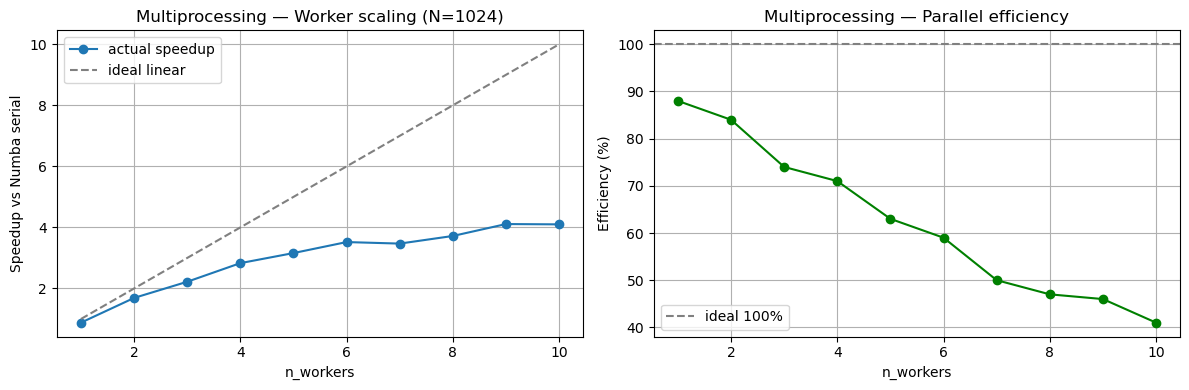

 workers |  time (s) |  speedup |  efficiency
------------------------------------------------
       1 |     0.040 |    0.88x |         88%
       2 |     0.021 |    1.69x |         84%
       3 |     0.016 |    2.22x |         74%
       4 |     0.013 |    2.83x |         71%
       5 |     0.011 |    3.16x |         63%
       6 |     0.010 |    3.52x |         59%
       7 |     0.010 |    3.47x |         50%
       8 |     0.010 |    3.72x |         47%
       9 |     0.009 |    4.11x |         46%
      10 |     0.009 |    4.10x |         41%

Comment: speedup grows continuously but efficiency drops each extra worker adds less benefit due to IPC overhead and diminishing parallelism at N1024.


In [26]:
n_workers_sweep = list(range(1, 11))
time_worker     = [0.040, 0.021, 0.016, 0.013, 0.011, 0.010, 0.010, 0.010, 0.009, 0.009]
speedup_worker  = [0.88,  1.69,  2.22,  2.83,  3.16,  3.52,  3.47,  3.72,  4.11,  4.10]
efficiency      = [88,    84,    74,    71,    63,    59,    50,    47,    46,    41]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(n_workers_sweep, speedup_worker, marker='o', label='actual speedup')
ax1.plot(n_workers_sweep, n_workers_sweep, linestyle='--', color='gray', label='ideal linear')
ax1.set_xlabel('n_workers')
ax1.set_ylabel('Speedup vs Numba serial')
ax1.set_title('Multiprocessing — Worker scaling (N=1024)')
ax1.legend()
ax1.grid(True)

ax2.plot(n_workers_sweep, efficiency, marker='o', color='green')
ax2.axhline(y=100, linestyle='--', color='gray', label='ideal 100%')
ax2.set_xlabel('n_workers')
ax2.set_ylabel('Efficiency (%)')
ax2.set_title('Multiprocessing — Parallel efficiency')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"{'workers':>8} | {'time (s)':>9} | {'speedup':>8} | {'efficiency':>11}")
print("-" * 48)
for i in range(len(n_workers_sweep)):
    print(f"{n_workers_sweep[i]:>8} | {time_worker[i]:>9.3f} | {speedup_worker[i]:>7.2f}x | {efficiency[i]:>10}%")

print("\nComment: speedup grows continuously but efficiency drops each extra worker "
      "adds less benefit due to IPC overhead and diminishing parallelism at N1024.")

---
## Section 2 — Dask Local
**Implementation:** `mandelbrot_dask.py` with `LocalCluster`, `dask.delayed` over Numba chunks  
**Hardware:** MacBook Air Apple Silicon, n_workers=10  

### 2.1 Chunk sweep at N=1024 (L06-M2)

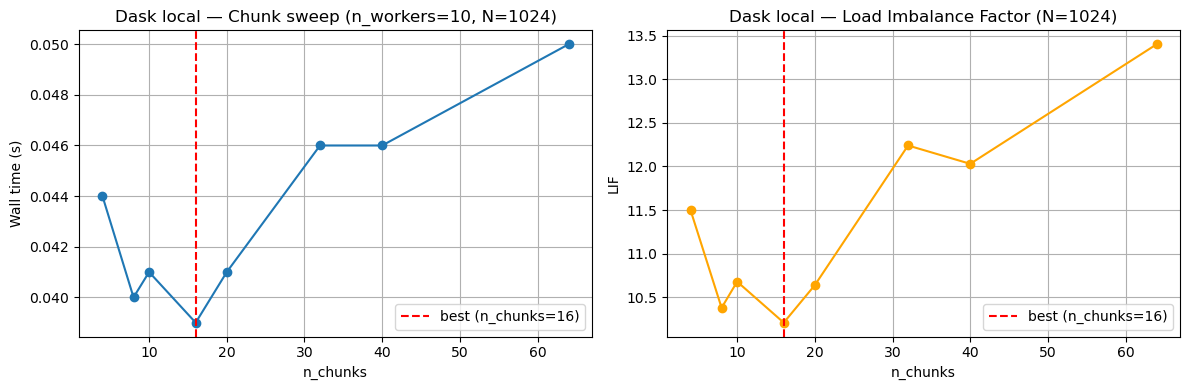

Best: n_chunks=16, wall time=0.039s, speedup=0.89x vs Numba serial
Comment: Dask local is indeed SLOWER than Numba single core at N= 1024. Scheduling overhead dominates when compute per chunk is small. LIF above 10 confirms workers spend most time waiting, not computing.


In [15]:
n_chunks_dask_local_1024 = [4,     8,     10,    16,    20,    32,    40,    64]
time_dask_local_1024     = [0.044, 0.040, 0.041, 0.039, 0.041, 0.046, 0.046, 0.050]
speedup_dask_local_1024  = [0.80,  0.88,  0.86,  0.89,  0.86,  0.76,  0.77,  0.69]
lif_dask_local_1024      = [11.50, 10.38, 10.68, 10.21, 10.64, 12.24, 12.03, 13.40]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(n_chunks_dask_local_1024, time_dask_local_1024, marker='o')
ax1.axvline(x=16, color='red', linestyle='--', label='best (n_chunks=16)')
ax1.set_xlabel('n_chunks')
ax1.set_ylabel('Wall time (s)')
ax1.set_title('Dask local — Chunk sweep (n_workers=10, N=1024)')
ax1.legend()
ax1.grid(True)

ax2.plot(n_chunks_dask_local_1024, lif_dask_local_1024, marker='o', color='orange')
ax2.axvline(x=16, color='red', linestyle='--', label='best (n_chunks=16)')
ax2.set_xlabel('n_chunks')
ax2.set_ylabel('LIF')
ax2.set_title('Dask local — Load Imbalance Factor (N=1024)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("Best: n_chunks=16, wall time=0.039s, speedup=0.89x vs Numba serial")
print("Comment: Dask local is indeed SLOWER than Numba single core at N= 1024. "
      "Scheduling overhead dominates when compute per chunk is small. "
      "LIF above 10 confirms workers spend most time waiting, not computing.")

### 2.2 Chunk sweep at N=4096 (L06-M3)
At larger grids, compute per chunk grows and Dask overhead becomes relatively smaller.

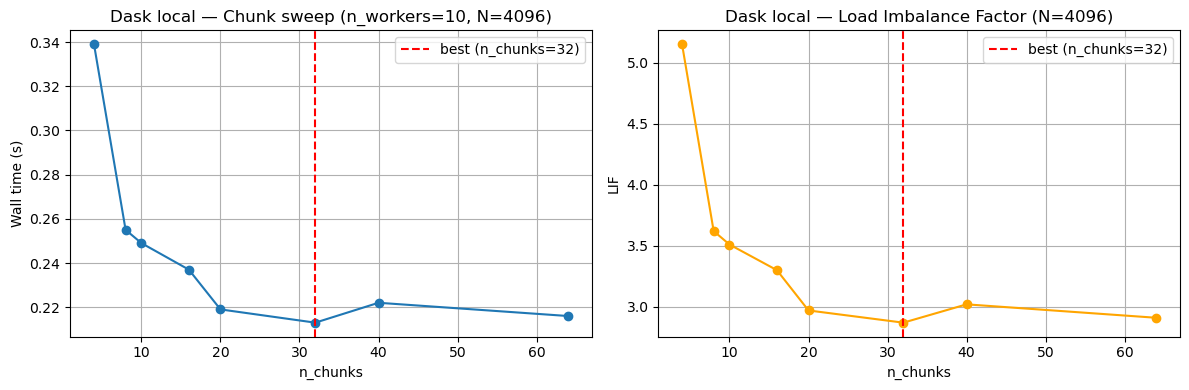

Numba serial baseline (N=4096): 0.551s
Best: n_chunks=32, wall time=0.213s, speedup=2.59x vs Numba serial
Comment: at N=4096 Dask local achieves 2.59x speedup over Numba single- core. Scheduling overhead is still visible (LIF approximately 2.87) but compute now dominates. Best n_chunks shifts from 16 (N=1024) to 32 (N= 4096) larger grid benefits from more chunks to keep all 10 workers busy.


In [16]:
t_serial_4096 = 0.551  # Numba single-core at N=4096

n_chunks_dask_local_4096 = [4,     8,     10,    16,    20,    32,    40,    64]
time_dask_local_4096     = [0.339, 0.255, 0.249, 0.237, 0.219, 0.213, 0.222, 0.216]
speedup_dask_local_4096  = [1.63,  2.17,  2.22,  2.33,  2.52,  2.59,  2.48,  2.56]
lif_dask_local_4096      = [5.15,  3.62,  3.51,  3.30,  2.97,  2.87,  3.02,  2.91]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(n_chunks_dask_local_4096, time_dask_local_4096, marker='o')
ax1.axvline(x=32, color='red', linestyle='--', label='best (n_chunks=32)')
ax1.set_xlabel('n_chunks')
ax1.set_ylabel('Wall time (s)')
ax1.set_title('Dask local — Chunk sweep (n_workers=10, N=4096)')
ax1.legend()
ax1.grid(True)

ax2.plot(n_chunks_dask_local_4096, lif_dask_local_4096, marker='o', color='orange')
ax2.axvline(x=32, color='red', linestyle='--', label='best (n_chunks=32)')
ax2.set_xlabel('n_chunks')
ax2.set_ylabel('LIF')
ax2.set_title('Dask local — Load Imbalance Factor (N=4096)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Numba serial baseline (N=4096): {t_serial_4096:.3f}s")
print("Best: n_chunks=32, wall time=0.213s, speedup=2.59x vs Numba serial")
print("Comment: at N=4096 Dask local achieves 2.59x speedup over Numba single- core. "
      "Scheduling overhead is still visible (LIF approximately 2.87) but compute now dominates. "
      "Best n_chunks shifts from 16 (N=1024) to 32 (N= 4096) larger grid benefits "
      "from more chunks to keep all 10 workers busy.")

---
## Section 3 — Dask Distributed (Strato Cluster)
**Implementation:** `mandelbrot_dask.py` with `Client("tcp://10.92.1.164:8786")`  
**Cluster config:** 2 worker VMs (AAU.CPU.b.2-4, 2 vCPUs each) = 4 worker processes  
**Code change from local:** `Client("tcp://10.92.1.164:8786")` instead of `LocalCluster`; removed `cluster.close()`  
**Grid:** N=4096, max_iter=100  
**Numba serial baseline at N=4096 (on cluster VM):** 1.274s

### 3.1 Chunk sweep (Experiment 1 — all 4 workers connected)

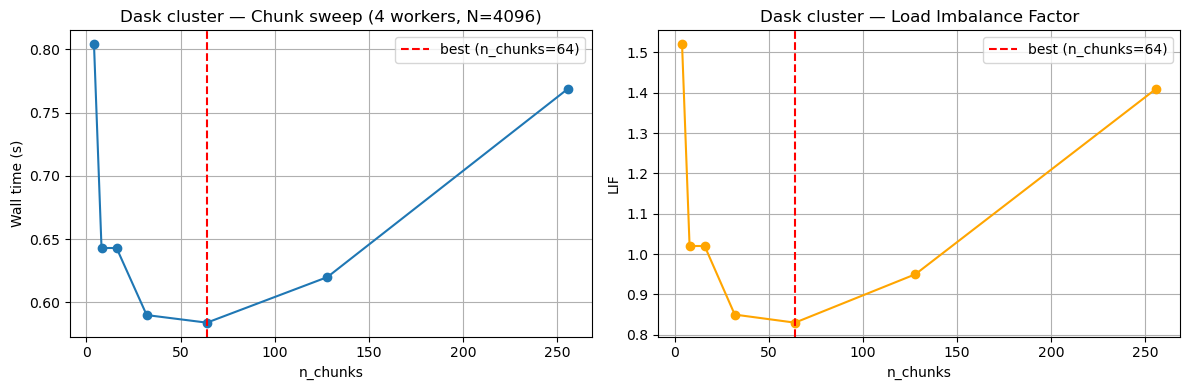

  n_chunks |  time (s) |  speedup |    LIF
--------------------------------------------
         4 |     0.804 |    1.58x |   1.52
         8 |     0.643 |    1.98x |   1.02
        16 |     0.643 |    1.98x |   1.02
        32 |     0.590 |    2.16x |   0.85
        64 |     0.584 |    2.18x |   0.83 <-- best
       128 |     0.620 |    2.06x |   0.95
       256 |     0.769 |    1.66x |   1.41

Best: n_chunks=64, wall time=0.584s, speedup=2.18x
Compare to Dask local best at N=4096: n_chunks=32.
Cluster favors larger chunks — network overhead (~10-50ms/task) is higher than IPC overhead (~1-5ms/task), so fewer, bigger chunks are more efficient.


In [17]:
t_serial_cluster = 1.274  # Numba serial on head node VM at N=4096

n_chunks_cluster = [4,     8,     16,    32,    64,    128,   256]
time_cluster     = [0.804, 0.643, 0.643, 0.590, 0.584, 0.620, 0.769]
speedup_cluster  = [1.58,  1.98,  1.98,  2.16,  2.18,  2.06,  1.66]
lif_cluster      = [1.52,  1.02,  1.02,  0.85,  0.83,  0.95,  1.41]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(n_chunks_cluster, time_cluster, marker='o')
ax1.axvline(x=64, color='red', linestyle='--', label='best (n_chunks=64)')
ax1.set_xlabel('n_chunks')
ax1.set_ylabel('Wall time (s)')
ax1.set_title('Dask cluster — Chunk sweep (4 workers, N=4096)')
ax1.legend()
ax1.grid(True)

ax2.plot(n_chunks_cluster, lif_cluster, marker='o', color='orange')
ax2.axvline(x=64, color='red', linestyle='--', label='best (n_chunks=64)')
ax2.set_xlabel('n_chunks')
ax2.set_ylabel('LIF')
ax2.set_title('Dask cluster — Load Imbalance Factor')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"{'n_chunks':>10} | {'time (s)':>9} | {'speedup':>8} | {'LIF':>6}")
print("-" * 44)
for i in range(len(n_chunks_cluster)):
    marker = " <-- best" if n_chunks_cluster[i] == 64 else ""
    print(f"{n_chunks_cluster[i]:>10} | {time_cluster[i]:>9.3f} | {speedup_cluster[i]:>7.2f}x | {lif_cluster[i]:>6.2f}{marker}")

print("\nBest: n_chunks=64, wall time=0.584s, speedup=2.18x")
print("Compare to Dask local best at N=4096: n_chunks=32.")
print("Cluster favors larger chunks — network overhead (~10-50ms/task) is higher "
      "than IPC overhead (~1-5ms/task), so fewer, bigger chunks are more efficient.")

### 3.2 Worker scaling (Experiment 2)
Fixed n_chunks=64, varying number of active worker VMs.

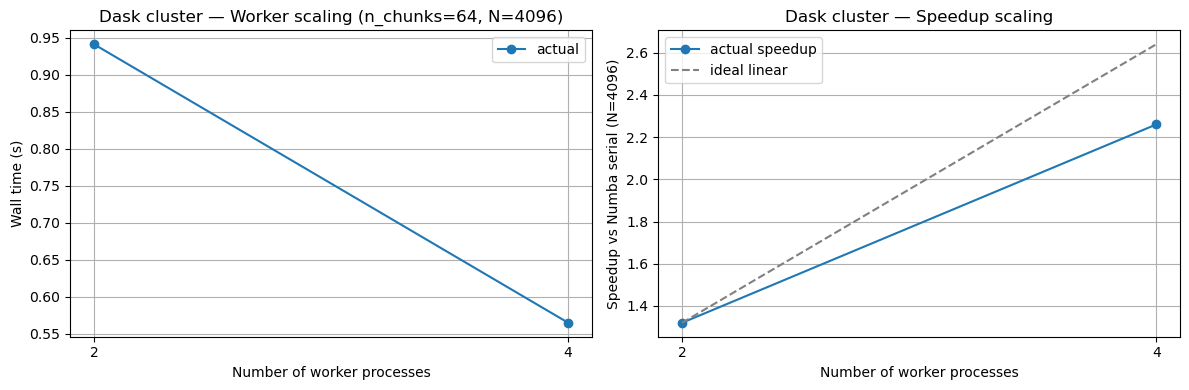

 VMs | Workers | Wall time |  Speedup
------------------------------------
   1 |       2 |     0.941s |    1.32x
   2 |       4 |     0.565s |    2.26x

Doubling workers (2 -> 4) reduces wall time from 0.941s to 0.565s (1.67x faster).
Speedup goes from 1.32x to 2.26x so almost linear scaling for this problem size.
Comment: scaling is almosst ideal. Network overhead is manageable at N=4096 because compute per chunk is large enough to amortize communication cost.


In [18]:
vms          = [1,     2]
workers      = [2,     4]
time_scaling = [0.941, 0.565]
speedup_scaling = [1.32, 2.26]

ideal = [w * speedup_scaling[0] / workers[0] for w in workers]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(workers, time_scaling, marker='o', label='actual')
ax1.set_xlabel('Number of worker processes')
ax1.set_ylabel('Wall time (s)')
ax1.set_title('Dask cluster — Worker scaling (n_chunks=64, N=4096)')
ax1.set_xticks(workers)
ax1.legend()
ax1.grid(True)

ax2.plot(workers, speedup_scaling, marker='o', label='actual speedup')
ax2.plot(workers, ideal, linestyle='--', color='gray', label='ideal linear')
ax2.set_xlabel('Number of worker processes')
ax2.set_ylabel('Speedup vs Numba serial (N=4096)')
ax2.set_title('Dask cluster — Speedup scaling')
ax2.set_xticks(workers)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"{'VMs':>4} | {'Workers':>7} | {'Wall time':>9} | {'Speedup':>8}")
print("-" * 36)
for i in range(len(vms)):
    print(f"{vms[i]:>4} | {workers[i]:>7} | {time_scaling[i]:>9.3f}s | {speedup_scaling[i]:>7.2f}x")

print("\nDoubling workers (2 -> 4) reduces wall time from 0.941s to 0.565s (1.67x faster).")
print("Speedup goes from 1.32x to 2.26x so almost linear scaling for this problem size.")
print("Comment: scaling is almosst ideal. Network overhead is manageable at N=4096 "
      "because compute per chunk is large enough to amortize communication cost.")

---
## Complete Performance Table

In [19]:
print("Serial implementations (MP1):")
print(f"{'Implementation':>25} | {'N':>6} | {'Runtime (s)':>11}")
print("-" * 50)
print(f"{'Naive Python':>25} | {'1024':>6} | {'1.175':>11}")
print(f"{'NumPy vectorised':>25} | {'1024':>6} | {'0.495':>11}")
print(f"{'Numba (single-core)':>25} | {'1024':>6} | {'0.035':>11}")
print(f"{'Numba (single-core)':>25} | {'4096':>6} | {'0.551':>11}")
print(f"{'Numba (single-core, VM)':>25} | {'4096':>6} | {'1.274':>11}")

print("\nParallel implementations (MP2):")
print(f"{'Implementation':>25} | {'N':>6} | {'Workers':>7} | {'Runtime (s)':>11} | {'Speedup vs Numba':>17}")
print("-" * 80)
rows = [
    ("Multiprocessing",    "1024", "5",  "0.011", "3.18x (same N)"),
    ("Dask local",         "1024", "10", "0.039", "0.89x (same N)"),
    ("Dask local",         "4096", "10", "0.213", "2.59x (same N)"),
    ("Dask cluster",       "4096", "4",  "0.565", "2.26x (VM Numba)"),
]
for impl, n, w, rt, sp in rows:
    print(f"{impl:>25} | {n:>6} | {w:>7} | {rt:>11} | {sp:>17}")

print("\nNote: Dask cluster speedup is relative to Numba single core on the same VM (1.274s).")
print("Multiprocessing and Dask local speedups are relative to Numba single-core on Mac (0.035s / 0.551s).")

Serial implementations (MP1):
           Implementation |      N | Runtime (s)
--------------------------------------------------
             Naive Python |   1024 |       1.175
         NumPy vectorised |   1024 |       0.495
      Numba (single-core) |   1024 |       0.035
      Numba (single-core) |   4096 |       0.551
  Numba (single-core, VM) |   4096 |       1.274

Parallel implementations (MP2):
           Implementation |      N | Workers | Runtime (s) |  Speedup vs Numba
--------------------------------------------------------------------------------
          Multiprocessing |   1024 |       5 |       0.011 |    3.18x (same N)
               Dask local |   1024 |      10 |       0.039 |    0.89x (same N)
               Dask local |   4096 |      10 |       0.213 |    2.59x (same N)
             Dask cluster |   4096 |       4 |       0.565 |  2.26x (VM Numba)

Note: Dask cluster speedup is relative to Numba single core on the same VM (1.274s).
Multiprocessing and Dask local

---
## MP3 — Section 1 — Computer Arithmetic
**Implementation:** `...` `...`   
**Hardware:** MacBook Air Apple Silicon, 

Looking at trajectory_divergence.png most pixels are blue meaning dloat32 and float64 trajectories separate very early.

Regarding the sensitivity_map.png the vast majority of pixels appear grey which means the perturbation didn't change the escape count.

## MP3 — Section 2 — Testing and documentation
**Implementation:** `...` `...`   
**Hardware:** MacBook Air Apple Silicon, 

In [22]:
# --- L09 M1 — Test Suite ---
print("M1 — Test Suite")
print(f"{'Test':>50} | {'Result':>6}")
print("-" * 60)
tests = [
    ("test_naive_pixel[0j-100-100]",          "PASSED"),
    ("test_naive_pixel[(5+0j)-100-0]",         "PASSED"),
    ("test_naive_pixel[(-3+0j)-100-0]",        "PASSED"),
    ("test_numba_pixel[0j-100-100]",           "PASSED"),
    ("test_numba_pixel[(5+0j)-100-1]",         "PASSED"),
    ("test_numba_pixel[(-2.5+0j)-100-1]",      "PASSED"),
    ("test_numpy_matches_naive_on_small_grid",  "PASSED"),
    ("test_parallel_matches_serial_on_small_grid", "PASSED"),
]
for name, result in tests:
    print(f"{name:>50} | {result:>6}")

print("\nTotal: 8 passed, 0 failed")
print("Coverage: 16% total (mandelbrot_naive 50%, mandelbrot_numpy 51%, mandelbrot_parallel 23%)")
print("Note: low total % expected — benchmark/plot/I/O code excluded by design")

M1 — Test Suite
                                              Test | Result
------------------------------------------------------------
                      test_naive_pixel[0j-100-100] | PASSED
                    test_naive_pixel[(5+0j)-100-0] | PASSED
                   test_naive_pixel[(-3+0j)-100-0] | PASSED
                      test_numba_pixel[0j-100-100] | PASSED
                    test_numba_pixel[(5+0j)-100-1] | PASSED
                 test_numba_pixel[(-2.5+0j)-100-1] | PASSED
            test_numpy_matches_naive_on_small_grid | PASSED
        test_parallel_matches_serial_on_small_grid | PASSED

Total: 8 passed, 0 failed
Coverage: 16% total (mandelbrot_naive 50%, mandelbrot_numpy 51%, mandelbrot_parallel 23%)
Note: low total % expected — benchmark/plot/I/O code excluded by design


In [23]:
# --- L09 M2 — Docstrings + Type Hints + ruff ---
print("M2 — Docstrings + Type Hints")
print("File: mandelbrot_parallel.py")
print("Functions documented: mandelbrot_pixel, mandelbrot_chunk, mandelbrot_serial, mandelbrot_parallel")
print("Type hints: all parameters and return values annotated")
print("ruff check: 0 errors")
print("ruff format: 1 file reformatted")

M2 — Docstrings + Type Hints
File: mandelbrot_parallel.py
Functions documented: mandelbrot_pixel, mandelbrot_chunk, mandelbrot_serial, mandelbrot_parallel
Type hints: all parameters and return values annotated
ruff check: 0 errors
ruff format: 1 file reformatted


## MP3 — Section 3 — GPU Computing
**Implementation:** `...` `...`   
**Hardware:** MacBook Air Apple Silicon, 

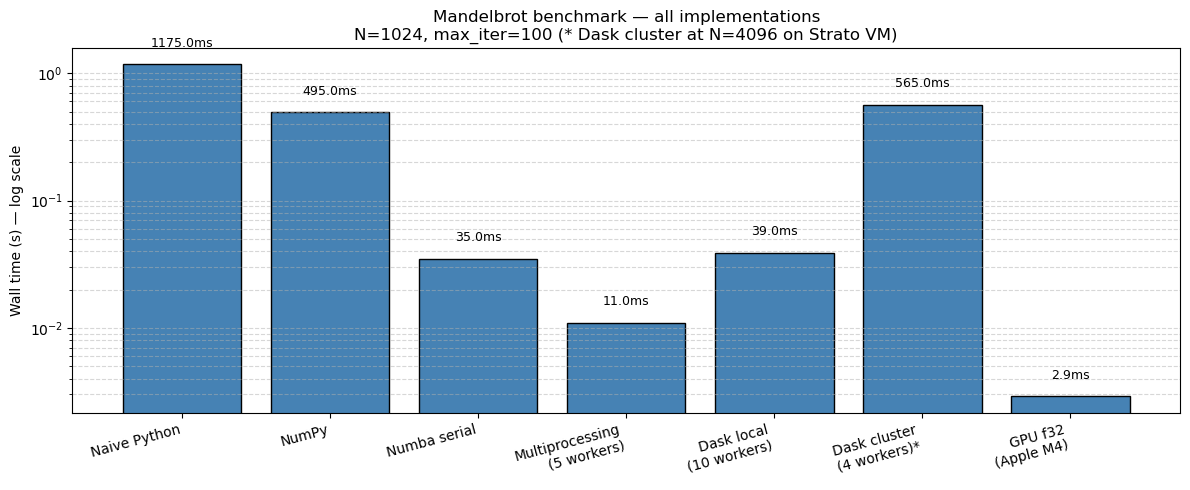

                Implementation |  time (ms) |  speedup vs naive
-----------------------------------------------------------------
                  Naive Python |     1175.0 |              1.0x
                         NumPy |      495.0 |              2.4x
                  Numba serial |       35.0 |             33.6x
   Multiprocessing (5 workers) |       11.0 |            106.8x
       Dask local (10 workers) |       39.0 |             30.1x
     Dask cluster (4 workers)* |      565.0 |              2.1x
            GPU f32 (Apple M4) |        2.9 |            405.2x

* Dask cluster measured at N=4096 on Strato VM — not directly comparable.
GPU f32 is 12.1x faster than Numba serial.


In [21]:
results = {
    "Naive Python":       1.175,
    "NumPy":              0.495,
    "Numba serial":       0.035,
    "Multiprocessing\n(5 workers)": 0.011,
    "Dask local\n(10 workers)":     0.039,
    "Dask cluster\n(4 workers)*":   0.565,
    "GPU f32\n(Apple M4)":          0.0029,
}

names, times = zip(*results.items())

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(names, times, log=True, color="steelblue", edgecolor="black")

# label each bar with its value
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.3,
            f"{t*1e3:.1f}ms", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Wall time (s) — log scale")
ax.set_title("Mandelbrot benchmark — all implementations\nN=1024, max_iter=100 "
             "(* Dask cluster at N=4096 on Strato VM)")
ax.grid(axis="y", which="both", linestyle="--", alpha=0.5)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("benchmark_mp3.png", dpi=150)
plt.show()

print(f"{'Implementation':>30} | {'time (ms)':>10} | {'speedup vs naive':>17}")
print("-" * 65)
t_naive = results["Naive Python"]
for name, t in results.items():
    label = name.replace("\n", " ")
    print(f"{label:>30} | {t*1e3:>10.1f} | {t_naive/t:>16.1f}x")

print("\n* Dask cluster measured at N=4096 on Strato VM — not directly comparable.")
t_gpu = results["GPU f32\n(Apple M4)"]
print(f"GPU f32 is {results['Numba serial'] / t_gpu:.1f}x faster than Numba serial.")